# FR5 BC 训练历史分析

这个 notebook 用来肉眼分析行为克隆训练效率和过拟合。它会读取 `demo/fr5_demo/data/il_policies/*.history.json`，绘制训练/验证 loss、泛化 gap、过拟合指标和一个用于观察的回归版“score”。

注意：当前 history 只有 `train_loss` 和 `val_loss`，没有分类任务那种真实 accuracy。这里的 score 是从 loss 变换出来的可视化辅助指标，用来比较趋势，不等价于任务成功率。

In [11]:
from pathlib import Path
import json
import math

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'demo/fr5_demo').exists():
    # 如果 notebook 从自身目录打开，则回到项目根目录
    ROOT = Path('../../..').resolve()

HISTORY_DIR = ROOT / 'demo/fr5_demo/data/il_policies'
HISTORY_FILES = sorted(HISTORY_DIR.glob('*.history.json'))

print('project root:', ROOT)
print('history dir :', HISTORY_DIR)
for path in HISTORY_FILES:
    print(' -', path.name)

project root: /home/sanchez/gs_playground
history dir : /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies
 - fr5_bc_cnn_small_tape_bc_v1.history.json
 - fr5_bc_spatial_softmax_tape_bc_v1.history.json
 - fr5_bc_state_mlp_tape_bc_v1.history.json


In [12]:
def load_history(path: Path):
    data = json.loads(path.read_text(encoding='utf-8'))
    if isinstance(data, dict) and 'history' in data:
        data = data['history']
    rows = []
    for item in data:
        rows.append({
            'epoch': int(item['epoch']),
            'train_loss': float(item['train_loss']),
            'val_loss': float(item.get('val_loss', item['train_loss'])),
        })
    rows.sort(key=lambda x: x['epoch'])
    return rows

def as_arrays(rows):
    epoch = np.array([r['epoch'] for r in rows], dtype=np.int32)
    train = np.array([r['train_loss'] for r in rows], dtype=np.float64)
    val = np.array([r['val_loss'] for r in rows], dtype=np.float64)
    return epoch, train, val

histories = {path.stem.replace('.history', ''): load_history(path) for path in HISTORY_FILES}
print('loaded histories:', list(histories))

loaded histories: ['fr5_bc_cnn_small_tape_bc_v1', 'fr5_bc_spatial_softmax_tape_bc_v1', 'fr5_bc_state_mlp_tape_bc_v1']


## 1. 总览表

重点看：

- `best_val_epoch`：验证集最好的 epoch，通常是该模型最适合停止训练的位置。
- `final/best_val`：最终验证 loss 相对最优验证 loss 的恶化倍数，越接近 1 越好。
- `gap@final`：最终 `val_loss - train_loss`，越大越像过拟合。
- `val_improve_%`：验证 loss 相对第一轮下降百分比，越大代表训练有效。

In [13]:
summary = []
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    best_idx = int(np.argmin(val))
    final_gap = float(val[-1] - train[-1])
    final_ratio = float(val[-1] / max(train[-1], 1e-12))
    final_over_best = float(val[-1] / max(val[best_idx], 1e-12))
    val_improve = float((val[0] - val[best_idx]) / max(val[0], 1e-12) * 100.0)
    train_improve = float((train[0] - train[-1]) / max(train[0], 1e-12) * 100.0)
    summary.append({
        'run': name,
        'epochs': int(epoch[-1]),
        'best_val_epoch': int(epoch[best_idx]),
        'best_val_loss': float(val[best_idx]),
        'final_train_loss': float(train[-1]),
        'final_val_loss': float(val[-1]),
        'final/best_val': final_over_best,
        'gap@final': final_gap,
        'val/train@final': final_ratio,
        'val_improve_%': val_improve,
        'train_improve_%': train_improve,
    })

try:
    import pandas as pd
    display(pd.DataFrame(summary).sort_values('best_val_loss'))
except Exception:
    for row in sorted(summary, key=lambda x: x['best_val_loss']):
        print(json.dumps(row, indent=2))

{
  "run": "fr5_bc_spatial_softmax_tape_bc_v1",
  "epochs": 39,
  "best_val_epoch": 34,
  "best_val_loss": 0.00011029906771367292,
  "final_train_loss": 0.00012278894027428555,
  "final_val_loss": 0.00015595366777799397,
  "final/best_val": 1.4139164637622916,
  "gap@final": 3.316472750370842e-05,
  "val/train@final": 1.2700953964552928,
  "val_improve_%": 98.8812028919598,
  "train_improve_%": 99.19028329390741
}
{
  "run": "fr5_bc_cnn_small_tape_bc_v1",
  "epochs": 50,
  "best_val_epoch": 50,
  "best_val_loss": 0.000338279790908326,
  "final_train_loss": 0.0003075012908102903,
  "final_val_loss": 0.000338279790908326,
  "final/best_val": 1.0,
  "gap@final": 3.0778500098035705e-05,
  "val/train@final": 1.1000922630826424,
  "val_improve_%": 97.26865261149293,
  "train_improve_%": 98.01781991158104
}
{
  "run": "fr5_bc_state_mlp_tape_bc_v1",
  "epochs": 36,
  "best_val_epoch": 31,
  "best_val_loss": 0.0004108317226309319,
  "final_train_loss": 0.00040137851916639464,
  "final_val_loss"

## 2. Train / Val Loss 曲线

判断方式：

- train 和 val 一起下降：正常学习。
- train 继续下降但 val 不降或上升：开始过拟合。
- val 很早到最低点，然后长期震荡/变差：训练轮数太多或数据太少。

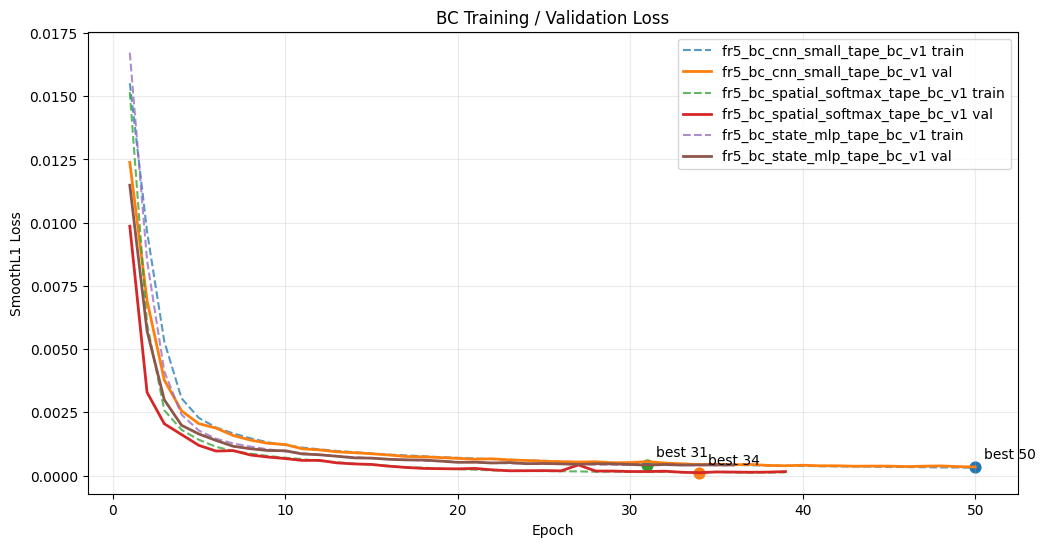

In [14]:
plt.figure(figsize=(12, 6))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    plt.plot(epoch, train, linestyle='--', alpha=0.75, label=f'{name} train')
    plt.plot(epoch, val, linewidth=2, label=f'{name} val')
    best_idx = int(np.argmin(val))
    plt.scatter([epoch[best_idx]], [val[best_idx]], s=60)
    plt.annotate(f'best {epoch[best_idx]}', (epoch[best_idx], val[best_idx]), textcoords='offset points', xytext=(6, 6))
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.title('BC Training / Validation Loss')
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

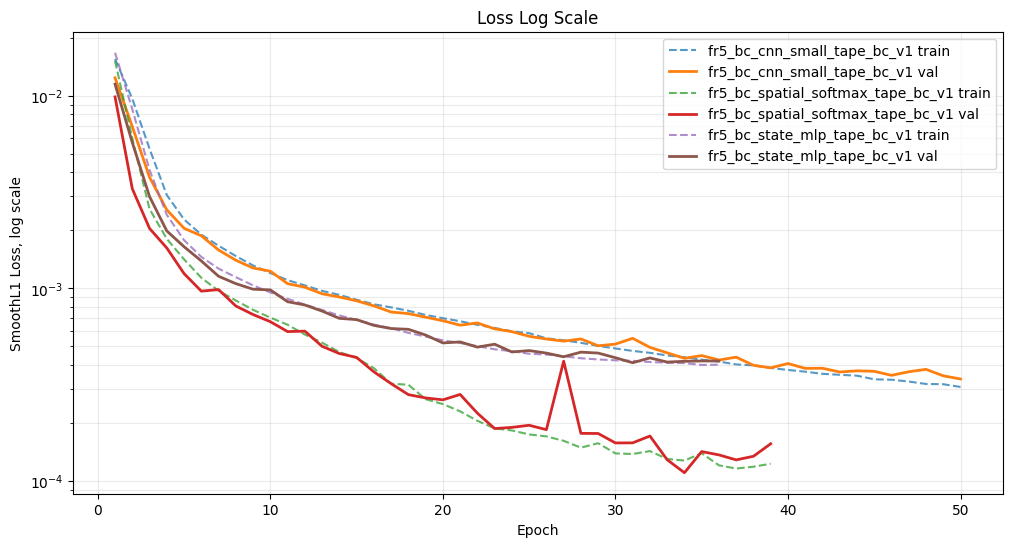

In [15]:
plt.figure(figsize=(12, 6))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    plt.semilogy(epoch, train, linestyle='--', alpha=0.75, label=f'{name} train')
    plt.semilogy(epoch, val, linewidth=2, label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss, log scale')
plt.title('Loss Log Scale')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

## 3. 过拟合观察：Generalization Gap

`gap = val_loss - train_loss`。

- gap 接近 0：训练集和验证集误差接近。
- gap 持续变大：模型越来越记住训练集，泛化变差。
- gap 为负：通常说明验证集太小、划分偶然性强，或者 train/val 分布不一致。

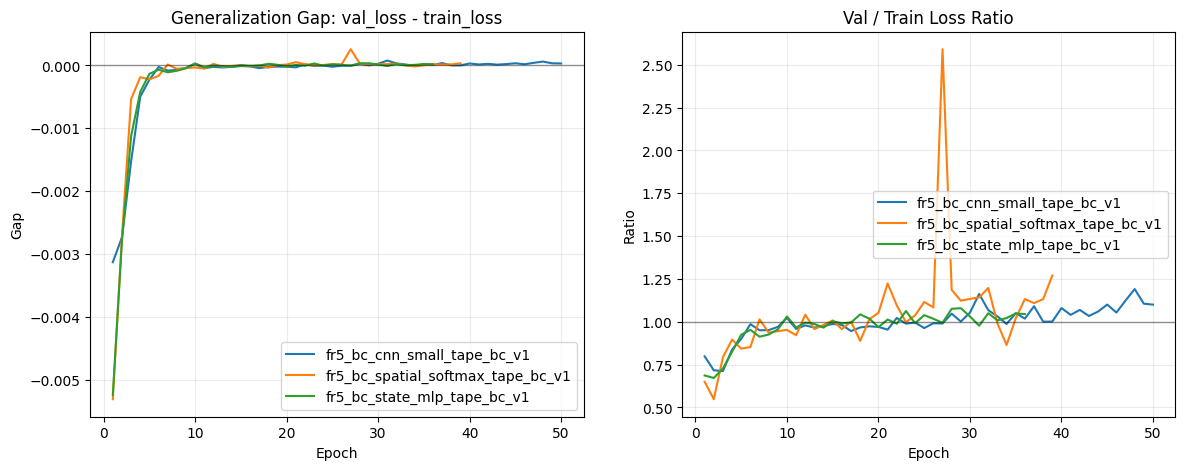

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    gap = val - train
    ratio = val / np.maximum(train, 1e-12)
    axes[0].plot(epoch, gap, label=name)
    axes[1].plot(epoch, ratio, label=name)
axes[0].axhline(0, color='black', linewidth=1, alpha=0.4)
axes[0].set_title('Generalization Gap: val_loss - train_loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Gap')
axes[0].grid(True, alpha=0.25)
axes[1].axhline(1, color='black', linewidth=1, alpha=0.4)
axes[1].set_title('Val / Train Loss Ratio')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Ratio')
axes[1].grid(True, alpha=0.25)
for ax in axes:
    ax.legend()
plt.show()

## 4. 回归版“准确度/score”趋势

BC 输出的是连续动作，不是分类标签，所以没有天然 accuracy。这里给两个辅助 score：

- `improvement_score = 1 - loss / first_val_loss`：相对第一轮验证 loss 的提升，越接近 1 越好。
- `bounded_score = 1 / (1 + loss)`：把 loss 压到 0~1，方便肉眼比较趋势。

真正的任务准确度还是要看 rollout 成功率，比如胶带是否套上 part1。

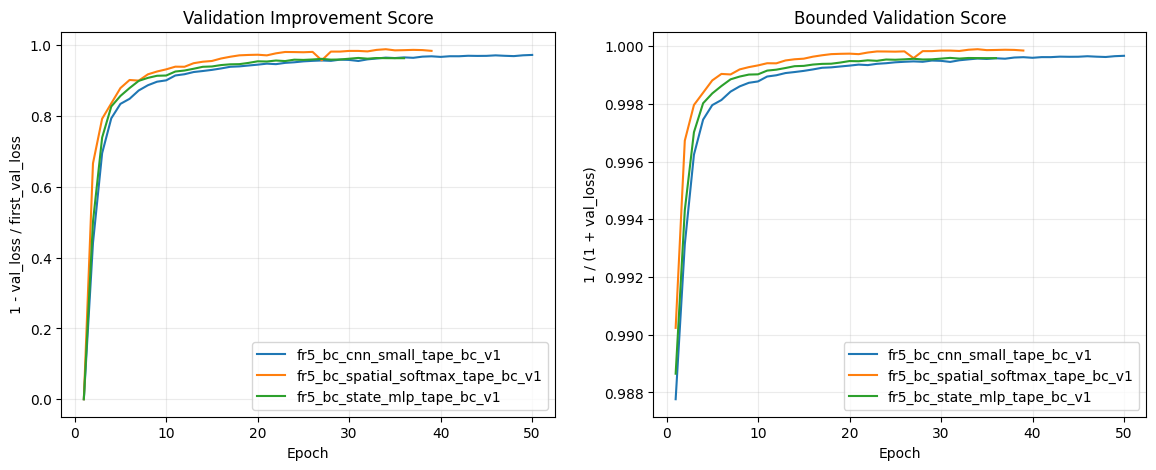

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    improvement_score = 1.0 - val / max(val[0], 1e-12)
    bounded_score = 1.0 / (1.0 + val)
    axes[0].plot(epoch, improvement_score, label=name)
    axes[1].plot(epoch, bounded_score, label=name)
axes[0].set_title('Validation Improvement Score')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('1 - val_loss / first_val_loss')
axes[0].grid(True, alpha=0.25)
axes[1].set_title('Bounded Validation Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('1 / (1 + val_loss)')
axes[1].grid(True, alpha=0.25)
for ax in axes:
    ax.legend()
plt.show()

## 5. 训练效率：每个 epoch 带来的收益

这张图看 `val_loss` 每轮下降多少。如果后期接近 0，说明继续训练收益很小；如果变成正数，说明验证 loss 在变差。

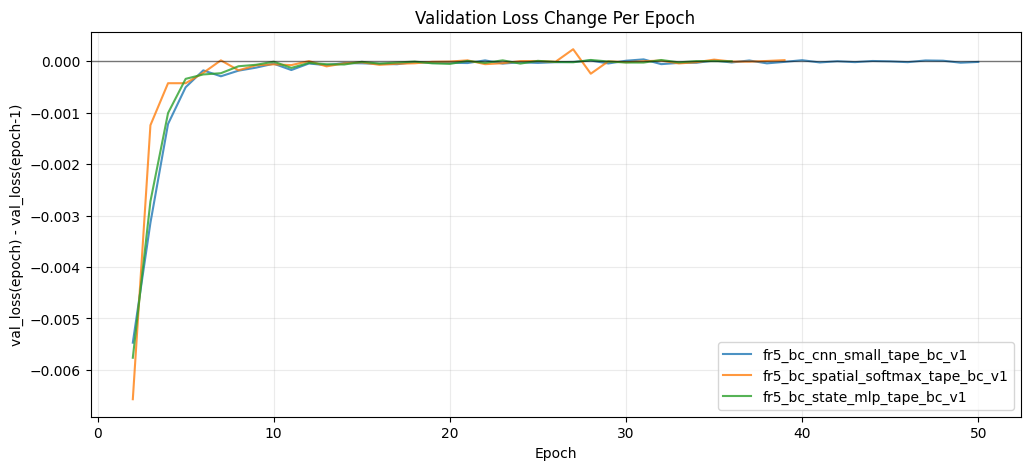

In [18]:
plt.figure(figsize=(12, 5))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    delta = np.r_[np.nan, val[1:] - val[:-1]]
    plt.plot(epoch, delta, alpha=0.8, label=name)
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.xlabel('Epoch')
plt.ylabel('val_loss(epoch) - val_loss(epoch-1)')
plt.title('Validation Loss Change Per Epoch')
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## 6. 自动给出 Early Stopping 建议

这里使用一个简单启发式：如果某个 epoch 之后，验证 loss 比历史最优高出 `patience_delta`，并且持续 `patience` 轮没有刷新最优，就认为应该早停。

In [19]:
def early_stop_epoch(epoch, val, patience=20, patience_delta=0.01):
    best = float('inf')
    best_epoch = int(epoch[0])
    stale = 0
    for e, loss in zip(epoch, val):
        if loss < best:
            best = float(loss)
            best_epoch = int(e)
            stale = 0
        elif loss > best * (1.0 + patience_delta):
            stale += 1
            if stale >= patience:
                return int(e), best_epoch, best
        else:
            stale = 0
    return None, best_epoch, best

for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    stop_epoch, best_epoch, best_val = early_stop_epoch(epoch, val, patience=20, patience_delta=0.01)
    print(f'[{name}] best_epoch={best_epoch}, best_val={best_val:.6f}, suggested_stop={stop_epoch}')
    if stop_epoch is None:
        print('  没有触发早停：要么还在改善，要么验证 loss 没有持续明显恶化。')
    else:
        print('  建议：后续训练可以在 best_epoch 附近保存/选模型，避免继续记忆训练集。')

[fr5_bc_cnn_small_tape_bc_v1] best_epoch=50, best_val=0.000338, suggested_stop=None
  没有触发早停：要么还在改善，要么验证 loss 没有持续明显恶化。
[fr5_bc_spatial_softmax_tape_bc_v1] best_epoch=34, best_val=0.000110, suggested_stop=None
  没有触发早停：要么还在改善，要么验证 loss 没有持续明显恶化。
[fr5_bc_state_mlp_tape_bc_v1] best_epoch=31, best_val=0.000411, suggested_stop=None
  没有触发早停：要么还在改善，要么验证 loss 没有持续明显恶化。


## 7. 毕设图表导出

运行下面 cell 会把论文/答辩可用的 PNG 图保存到 `demo/fr5_demo/data/il_policies/figures/`。

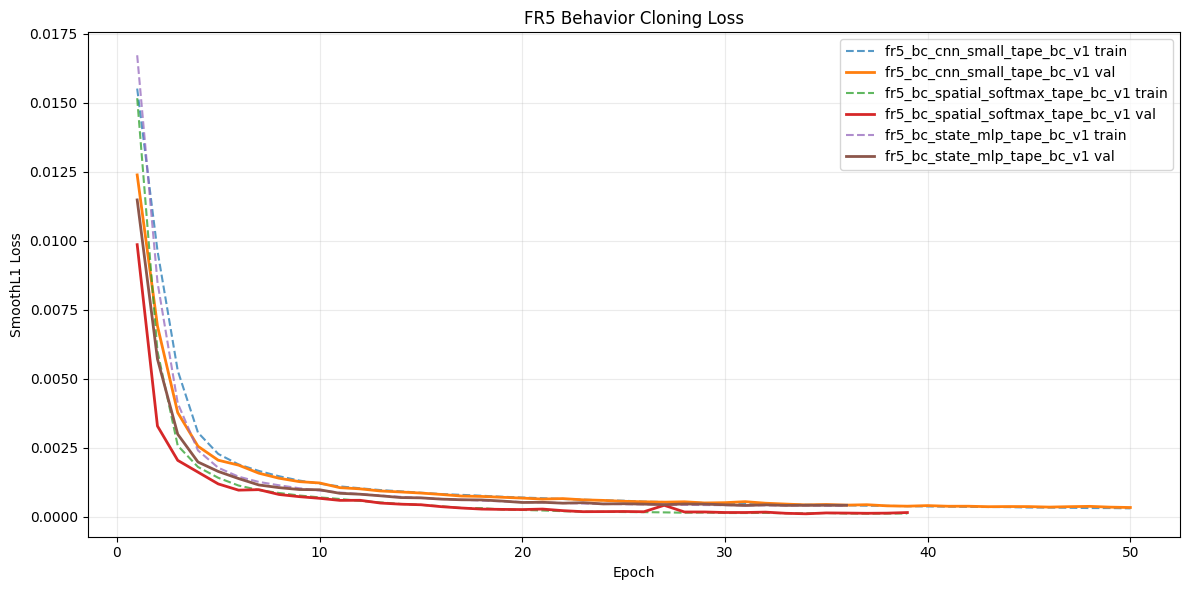

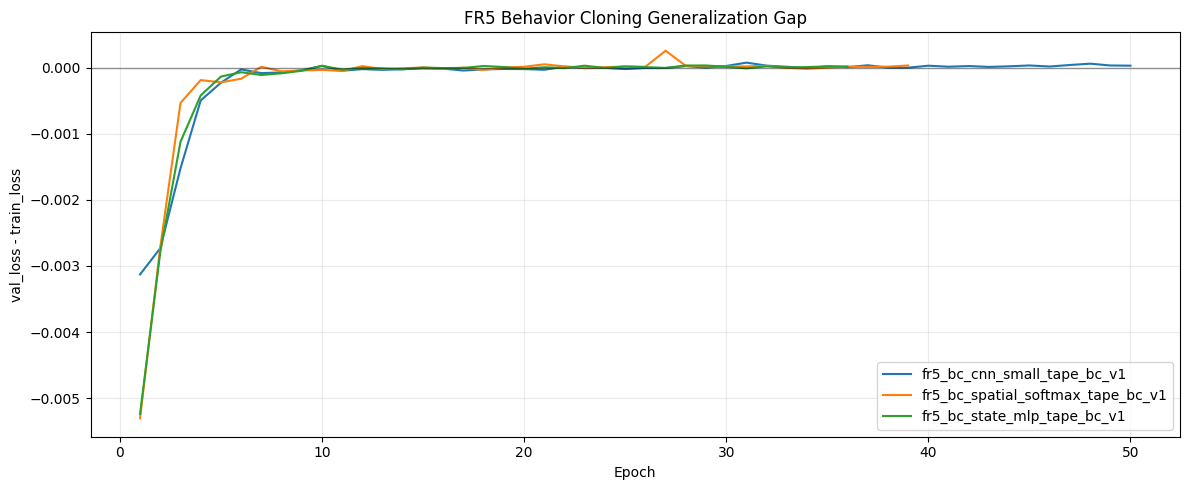

saved figures to: /home/sanchez/gs_playground/demo/fr5_demo/data/il_policies/figures


In [20]:
FIG_DIR = HISTORY_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    plt.plot(epoch, train, linestyle='--', alpha=0.75, label=f'{name} train')
    plt.plot(epoch, val, linewidth=2, label=f'{name} val')
plt.xlabel('Epoch')
plt.ylabel('SmoothL1 Loss')
plt.title('FR5 Behavior Cloning Loss')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'bc_loss_curves.png', dpi=180)
plt.show()

plt.figure(figsize=(12, 5))
for name, rows in histories.items():
    epoch, train, val = as_arrays(rows)
    plt.plot(epoch, val - train, label=name)
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.xlabel('Epoch')
plt.ylabel('val_loss - train_loss')
plt.title('FR5 Behavior Cloning Generalization Gap')
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'bc_generalization_gap.png', dpi=180)
plt.show()

print('saved figures to:', FIG_DIR)